In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import numpy as np
from pathlib import Path 

dir = "benchmark_results/"
path = Path(dir)
DS = []
dfs = []

for p in path.iterdir():
    pattern = r".*/bench_(.*).csv"
    name = re.search(pattern, str(p)).group(1)
    DS.append(name)
    df = pd.read_csv(p)
    df["size"] =  df["name"].str.split("/").str[1].astype("float64")
    df["op"] = df["name"].str.extract(r"BM_([^/<]+)")
    dfs.append((df, name))

''''
df_beap = pd.read_csv("benchmark_results/bench_beap.csv")
df_heap = pd.read_csv("benchmark_results/bench_heap.csv")
df_bst = pd.read_csv("benchmark_results/bench_bst.csv")
df_1beap = pd.read_csv("benchmark_results/bench_1-nbeap.csv")
df_2beap = pd.read_csv("benchmark_results/bench_2-nbeap.csv")
df_3beap = pd.read_csv("benchmark_results/bench_3-nbeap.csv")
df_4beap = pd.read_csv("benchmark_results/bench_4-nbeap.csv")
df_5beap = pd.read_csv("benchmark_results/bench_5-nbeap.csv")
df_6beap = pd.read_csv("benchmark_results/bench_6-nbeap.csv")
df_7beap = pd.read_csv("benchmark_results/bench_7-nbeap.csv")
df_8beap = pd.read_csv("benchmark_results/bench_8-nbeap.csv")
df_9beap = pd.read_csv("benchmark_results/bench_9-nbeap.csv")
df_10beap = pd.read_csv("benchmark_results/bench_10-nbeap.csv")

dfs  = [(df_beap, "beap"),
        (df_heap, "heap"),
        (df_bst, "bst"),
        (df_1beap, "1-beap"),
        (df_2beap, "2-beap"),
        (df_3beap, "3-beap"),
        (df_4beap, "4-beap"),
        (df_5beap, "5-beap"),
        (df_6beap, "6-beap"),
        (df_7beap, "7-beap"),
        (df_8beap, "8-beap"),
        (df_9beap, "9-beap"),
        (df_10beap, "10-beap"),
    ]

for df, _ in dfs:
    df["size"] =  df["name"].str.split("/").str[1].astype("float64")
    df["op"] = df["name"].str.extract(r"BM_([^/<]+)")
'''

'\'\ndf_beap = pd.read_csv("benchmark_results/bench_beap.csv")\ndf_heap = pd.read_csv("benchmark_results/bench_heap.csv")\ndf_bst = pd.read_csv("benchmark_results/bench_bst.csv")\ndf_1beap = pd.read_csv("benchmark_results/bench_1-nbeap.csv")\ndf_2beap = pd.read_csv("benchmark_results/bench_2-nbeap.csv")\ndf_3beap = pd.read_csv("benchmark_results/bench_3-nbeap.csv")\ndf_4beap = pd.read_csv("benchmark_results/bench_4-nbeap.csv")\ndf_5beap = pd.read_csv("benchmark_results/bench_5-nbeap.csv")\ndf_6beap = pd.read_csv("benchmark_results/bench_6-nbeap.csv")\ndf_7beap = pd.read_csv("benchmark_results/bench_7-nbeap.csv")\ndf_8beap = pd.read_csv("benchmark_results/bench_8-nbeap.csv")\ndf_9beap = pd.read_csv("benchmark_results/bench_9-nbeap.csv")\ndf_10beap = pd.read_csv("benchmark_results/bench_10-nbeap.csv")\n\ndfs  = [(df_beap, "beap"),\n        (df_heap, "heap"),\n        (df_bst, "bst"),\n        (df_1beap, "1-beap"),\n        (df_2beap, "2-beap"),\n        (df_3beap, "3-beap"),\n        (df

In [61]:
# DS = [ ds for (_, ds) in dfs]
DS_sorted = sorted(DS)
colors = [plt.get_cmap("tab20")(i) for i in np.linspace(0, 1, len(DS_sorted))]
color_map = dict(zip(DS_sorted, colors))

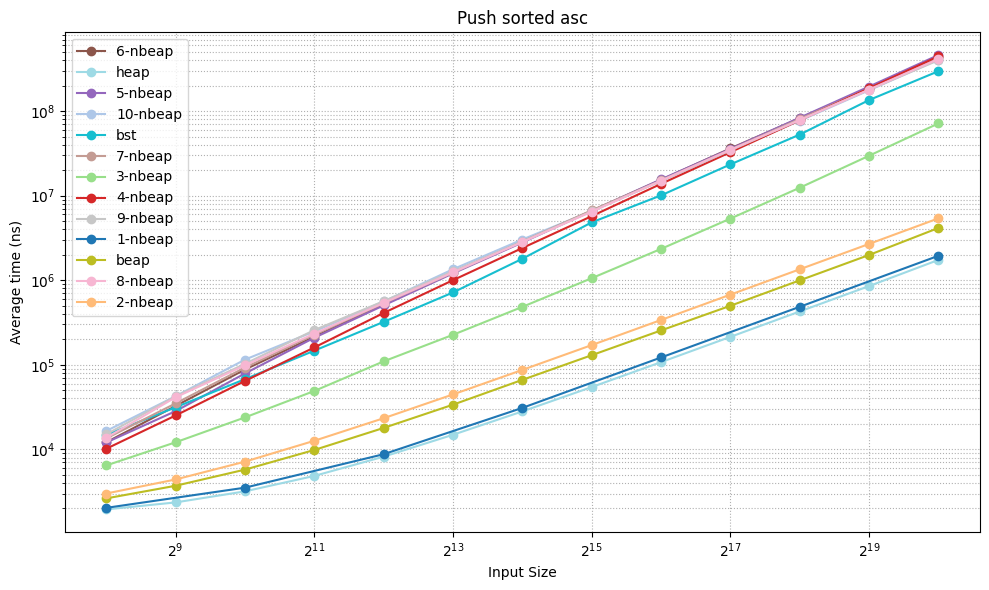

In [62]:
# push sorted asc
plt.figure(figsize=(10, 6))
plt.title(f"Push sorted asc")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "PushSortedAsc"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

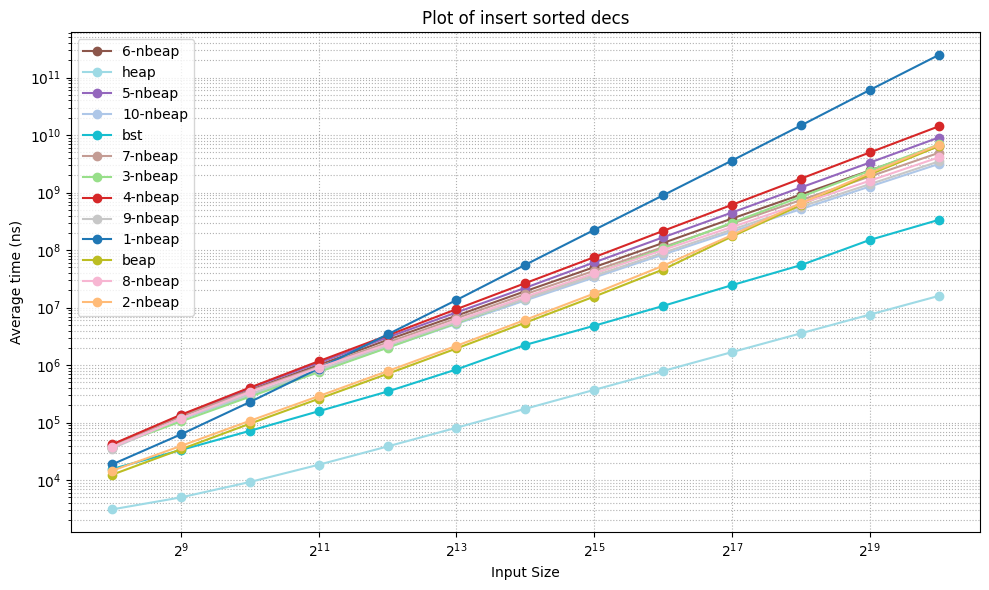

In [63]:
# insertion push sorted desc
plt.figure(figsize=(10, 6))
plt.title(f"Plot of insert sorted decs")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "PushSortedDesc"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

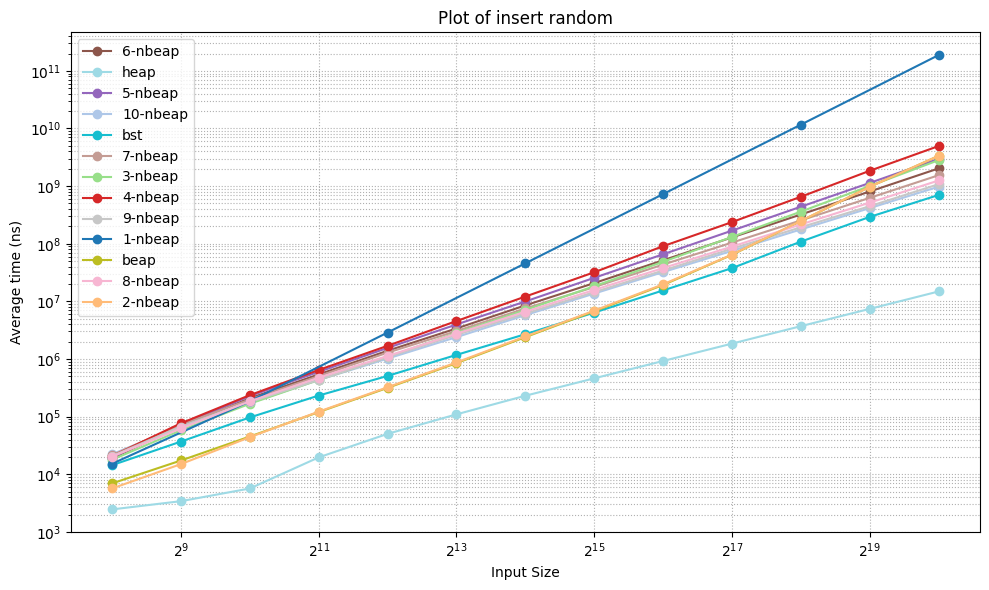

In [64]:
# insertion push random 
plt.figure(figsize=(10, 6))
plt.title(f"Plot of insert random")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "PushRandom"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

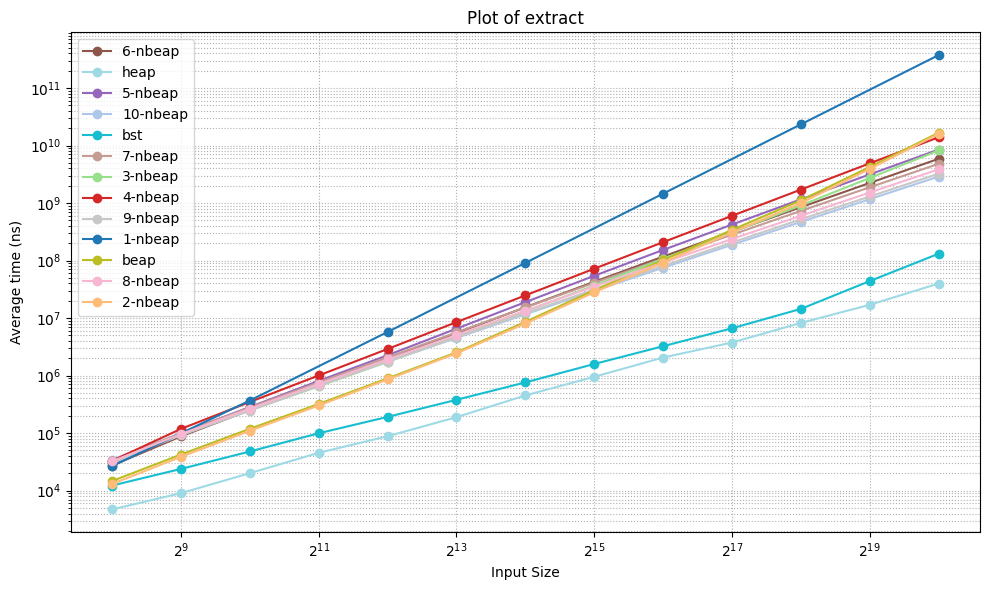

In [65]:
# insertion extract
plt.figure(figsize=(10, 6))
plt.title(f"Plot of extract")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "Extract"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

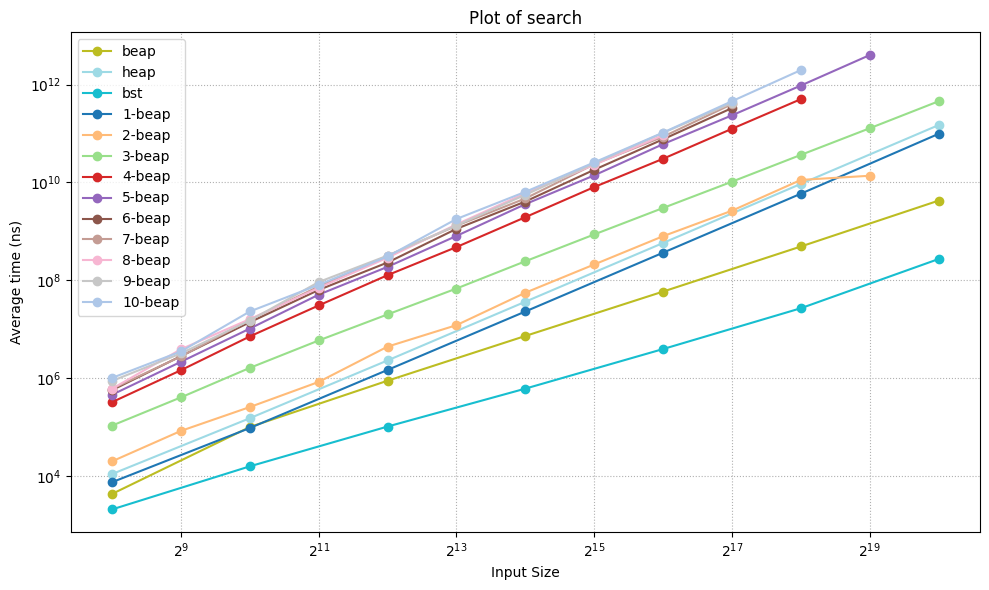

In [58]:
# insertion push sorted desc
plt.figure(figsize=(10, 6))
plt.title(f"Plot of search")
plt.xlabel("Input Size")
plt.ylabel("Average time (ns)")
plt.xscale("log", base=2)

for (df, ds) in dfs:
    df_op = df[df["op"] == "Search"].copy()
    df_op["size"] = pd.to_numeric(df_op["size"], errors="coerce")
    df_op["cpu_time"] = pd.to_numeric(df_op["cpu_time"], errors="coerce")
    df_op = df_op.sort_values("size")
    x = df_op["size"].to_numpy()
    y = df_op["cpu_time"].to_numpy()

    plt.plot(x, y, marker="o", label=ds, color=color_map[ds])

plt.grid(True, which="both", linestyle=":")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()